<a href="https://colab.research.google.com/github/aqilfiras/SMS-Classification/blob/main/SMS_Spam_CLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import torch
import torch.nn as nn
import gensim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Change device to 'cuda' if available

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option('future.no_silent_downcasting', True)

# Get the data

In [35]:
data = pd.read_csv('spam.csv', encoding='latin-1')
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
data = data.rename(columns={'v1': 'label', 'v2': 'text'})
print(data['label'].value_counts())
data = data.replace({'ham': 0, 'spam': 1})
data.head()

label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Set values for x and y

In [36]:
y_raw,X_raw = data['label'].copy().tolist(), data['text'].copy().str.lower().tolist()

# Select and load model

In [37]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device = 'cuda')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

# Convert the mails into embeddings

In [38]:
sentence_embeddings = model.encode(X_raw, convert_to_tensor=True )

In [39]:
sentence_embeddings.shape

torch.Size([5572, 384])

# Split into training, validation, and test set

In [40]:
X_temp, X_test, y_temp, y_test = train_test_split(sentence_embeddings, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

In [41]:
print(f"Train: {len(X_train)} ({len(X_train)/len(X_raw):.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X_raw):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_raw):.1%})")

Train: 3899 (70.0%)
Val:   558 (10.0%)
Test:  1115 (20.0%)


# Load and perform standard scaling on each set

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.cpu())
X_val = scaler.transform(X_val.cpu())
X_test = scaler.transform(X_test.cpu())

# Convert into pytorch tensors

In [43]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device = device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32, device = device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32, device = device).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device = device).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device = device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device = device).unsqueeze(1)

# Build the classifier class

In [44]:
class SpamClassifierMLP(nn.Module):
  def __init__(self):
    super(SpamClassifierMLP, self).__init__()
    self.hidden1 = nn.Linear(384, 128)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.3)
    self.hidden2 = nn.Linear(128, 32)
    self.output = nn.Linear(32, 1)

  def forward(self, x):
    x = self.hidden1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.hidden2(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.output(x)
    return x

# Load the model, criterion, and optimizer

In [45]:
num_ham = (y_train_tensor == 0).sum()
num_spam = (y_train_tensor == 1).sum()
pos_weight = torch.tensor([num_ham / num_spam], dtype=torch.float32)

In [46]:
model = SpamClassifierMLP().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Training the model

In [ ]:
best_val_loss = float('inf')
patience, counter = 10, 0

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load best model for final test evaluation
model.load_state_dict(torch.load('best_model.pt'))

# Evaluate model on the test set

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.89      0.96      0.92       149

    accuracy                           0.98      1115
   macro avg       0.94      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



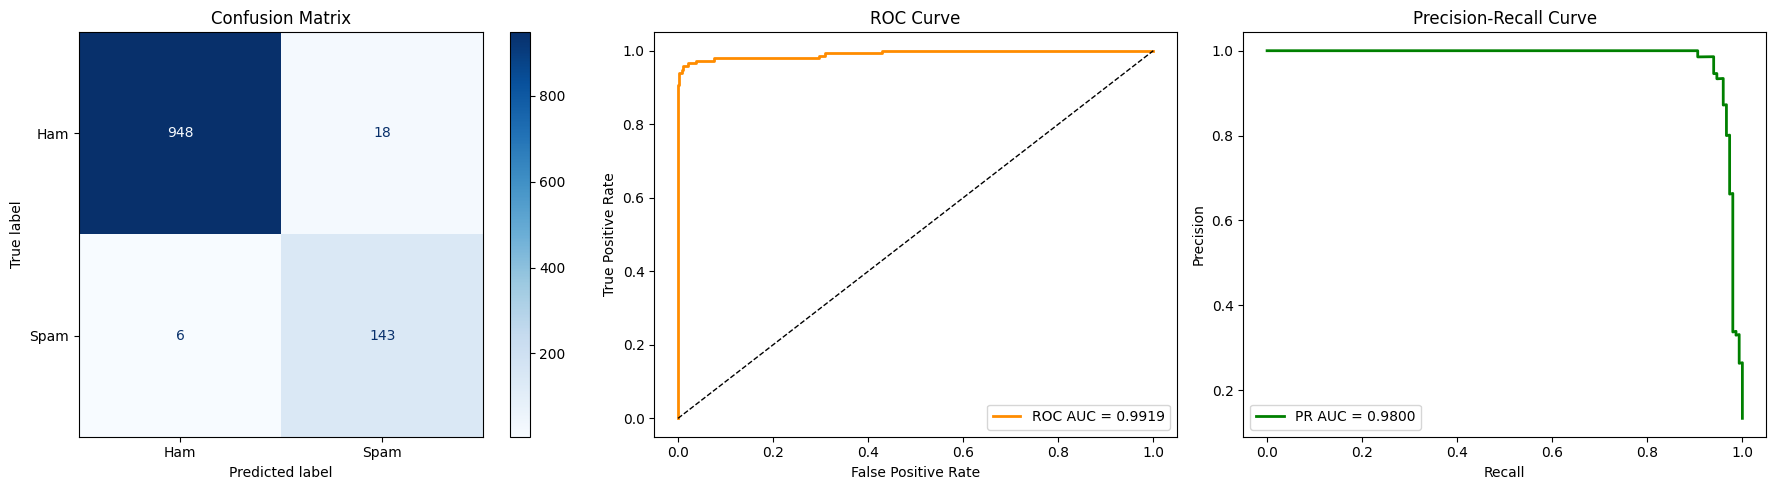

SUMMARY
ROC AUC:  0.9919
PR AUC:   0.9800
Accuracy: 0.9785


In [48]:
def evaluate(model, X_test_tensor, y_test_tensor):
  y_test_np = y_test_tensor.cpu().numpy().flatten()
  model.eval()
  with torch.no_grad():
      logits = model(X_test_tensor)
      probs = torch.sigmoid(logits).squeeze().cpu().numpy()
      preds = (probs > 0.5).astype(int)

  # --- 1. Classification Report ---
  print("=" * 50)
  print("CLASSIFICATION REPORT")
  print("=" * 50)
  print(classification_report(y_test_np, preds, target_names=["Ham", "Spam"]))

  # --- 2. Confusion Matrix ---
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))

  cm = confusion_matrix(y_test_np, preds)
  ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(ax=axes[0], cmap="Blues")
  axes[0].set_title("Confusion Matrix")

  # --- 3. ROC Curve ---
  fpr, tpr, _ = roc_curve(y_test_np, probs)
  roc_auc = roc_auc_score(y_test_np, probs)

  axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC AUC = {roc_auc:.4f}")
  axes[1].plot([0, 1], [0, 1], "k--", lw=1)
  axes[1].set_xlabel("False Positive Rate")
  axes[1].set_ylabel("True Positive Rate")
  axes[1].set_title("ROC Curve")
  axes[1].legend(loc="lower right")

  # --- 4. Precision-Recall Curve ---
  precision, recall, _ = precision_recall_curve(y_test_np, probs)
  pr_auc = average_precision_score(y_test_np, probs)

  axes[2].plot(recall, precision, color="green", lw=2, label=f"PR AUC = {pr_auc:.4f}")
  axes[2].set_xlabel("Recall")
  axes[2].set_ylabel("Precision")
  axes[2].set_title("Precision-Recall Curve")
  axes[2].legend(loc="lower left")

  plt.tight_layout()
  plt.show()

  # --- 5. Summary ---
  print("=" * 50)
  print("SUMMARY")
  print("=" * 50)
  print(f"ROC AUC:  {roc_auc:.4f}")
  print(f"PR AUC:   {pr_auc:.4f}")
  print(f"Accuracy: {(preds == y_test_np).mean():.4f}")

evaluate(model, X_test_tensor, y_test_tensor)